# COE 311K Final Project - Part 1 of 3

Karthik Gunaseelan, EID: kkg745, Project: Individual

# SECTION 1: Introduction and Model Selection

For this project, I am modeling a car suspension system as a spring-mass-damper system (Option A). This is a realistic engineering application because car suspensions are designed to reduce vertical motion after the car hits a bump, pothole, or uneven road surface. The system can be modeled as a second-order ordinary differential equation because the motion depends on displacement, velocity, and acceleration.


Governing Second-Order ODE (Format Taken From Claude):

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$

- m: Vehicle mass supported by one suspension
- c: Damping coefficient 
- k: Spring constant

Conversion to System of First-Order ODE's:

$$\frac{dy}{dt} = v$$


$$\frac{dv}{dt} = \frac{-cv-ky}{m}$$


- dy/dy = v: Change position in the vertical direction (vertical velocity)
- dv/dt: Change in vertical velocity (vertical acceleration)

# SECTION 2: Parameter Research and Justification

In [ ]:
citations after conlclusion.

# SECTION 3: Numerical Methods Implementation

Governing Second-Order ODE:

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$

System of First-Order ODE's:

$$\frac{dy_1}{dt} = y_2$$ $$\frac{dy_2}{dt} = f(t, y_1, y_2)$$

Applied To Spring-Mass-Damper System:

$$\frac{dy}{dt} = v$$ , $$\frac{dv}{dt} = \frac{-cv-ky}{m}$$

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters

m = 397.0 # Mass supported by one suspension (kg)
c = 1500.0 # Damping coefficient (N*s/m)
k = 15000.0 # Spring constant (N/m)
t_start = 0 # Initial time (s)
t_end = 5 # Final time (s)
y_0 = 0.05 # Initial displacement (m)
v_0 = 0.0 # Initial velocity (m/s)
h_values = np.array([0.1, 0.05, 0.01]) # 3 Different Step Sizes

# Function representing the second-order ODE converted to first-order system

def f(t, y, v):
    return -(c / m) * v - (k / m) * y

In [88]:
# Euler's Forward Method

def euler_method(h, m, c, k, t_start, t_end, y_0, v_0):
    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
       
        #Current Values
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # Euler update equations
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * f(t_n, y_n, v_n)
        
    return t_values, y_values, v_values

In [89]:
# RK4 Method for the system of first-order ODEs

def rk4_method(h, m, c, k, t_start, t_end, y_0, v_0):
    
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    
    for i in range(1, len(t_values)):
        
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        # k1 values
        k1_y = h * v_n
        k1_v = h * f(t_n, y_n, v_n)
        
        # k2 values
        k2_y = h * (v_n + k1_v / 2)
        k2_v = h * f(t_n + h / 2, y_n + k1_y / 2, v_n + k1_v / 2)
        
        # k3 values
        k3_y = h * (v_n + k2_v / 2)
        k3_v = h * f(t_n + h / 2, y_n + k2_y / 2, v_n + k2_v / 2)
        
        # k4 values
        k4_y = h * (v_n + k3_v)
        k4_v = h * f(t_n + h, y_n + k3_y, v_n + k3_v)
        
        # RK4 update equations
        y_values[i] = y_n + (k1_y + 2 * k2_y + 2 * k3_y + k4_y) / 6
        v_values[i] = v_n + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6
        
    return t_values, y_values, v_values

The governing second-order ODE was broken up into two first-order ODE's which were solved by the Euler's Forward Method and RK4 Method.

The first numerical method used was the Euler’s Forward Method. This method uses the current slope of the solution to estimate the next value. At each time step, the displacement is updated using the current velocity, and the velocity is updated using the current acceleration. However, its accuracy depends strongly on the step size, as larger step sizes may lead to higher error or instability.

The second numerical method used was the RK4 Method. RK4 improves accuracy by evalutation the slope at four locations/velocities within each time step respectively, rather than just one slope at the beginning of the interval. As a result, it has higher accuracy than Euler's Method, even with larger step sizes.

# SECTION 4: Solutions and Comparisons

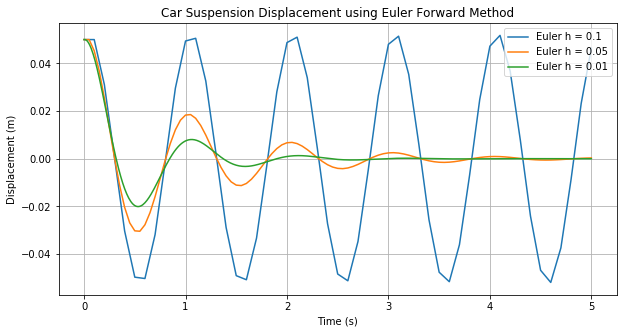

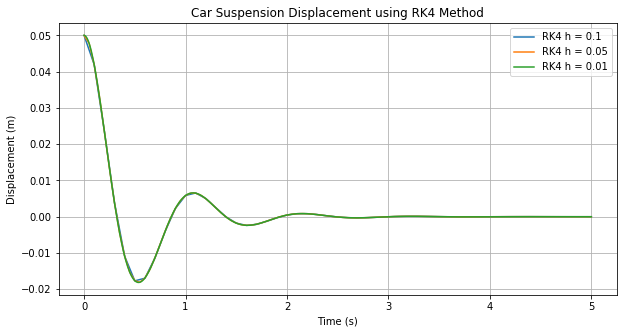

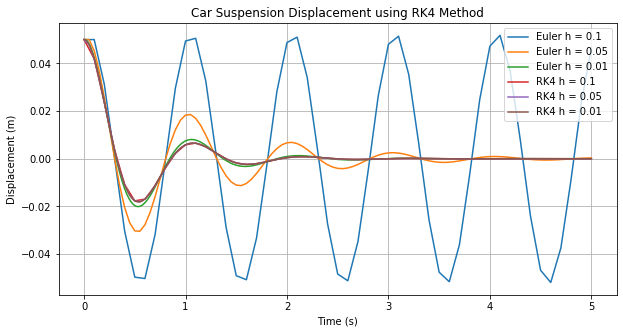

In [90]:
# Plot displacement for Euler's Forward Method
plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'Euler h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Car Suspension Displacement using Euler Forward Method')
plt.legend()
plt.grid(True)
plt.show()

# Plot displacement for RK4

plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Car Suspension Displacement using RK4 Method')
plt.legend()
plt.grid(True)
plt.show()

# Plot displacement for both in one graph

plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'Euler h = {h}')
    
for h in h_values:
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Car Suspension Displacement using RK4 Method')
plt.legend()
plt.grid(True)
plt.show()

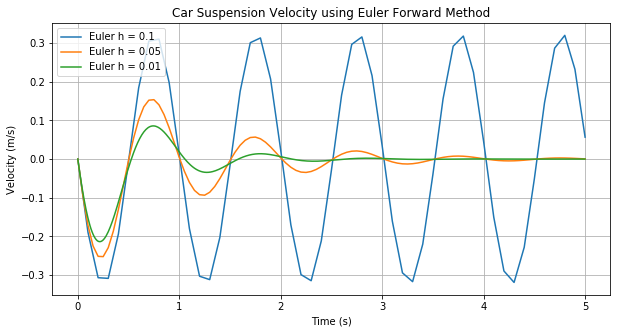

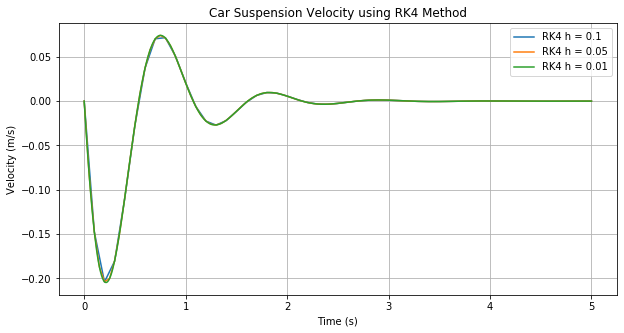

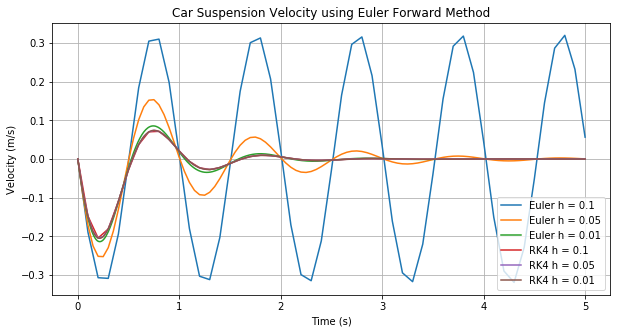

In [91]:
# Plot velocity for Euler's Forward Method

plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label=f'Euler h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Car Suspension Velocity using Euler Forward Method')
plt.legend()
plt.grid(True)
plt.show()

# Plot velocity for RK4

plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Car Suspension Velocity using RK4 Method')
plt.legend()
plt.grid(True)
plt.show()

# Plot velocity for both in one graph

plt.figure(figsize=(10, 5))

for h in h_values:
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label=f'Euler h = {h}')
    
for h in h_values:
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, v_values, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Car Suspension Velocity using Euler Forward Method')
plt.legend()
plt.grid(True)
plt.show()

The step solution . When h gets too large, the behavior of the ODE is not properly graphed.

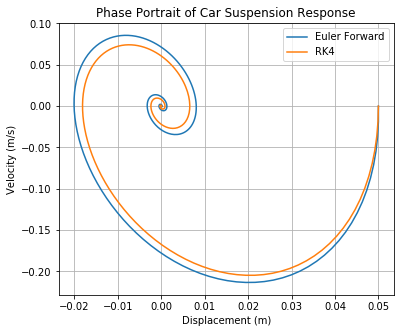

In [106]:
# Phase portrait

plt.figure(figsize=(6, 5))
plt.plot(y_euler, v_euler, label='Euler Forward')
plt.plot(y_rk4, v_rk4, label='RK4')
plt.xlabel('Displacement (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Phase Portrait of Car Suspension Response')
plt.legend()
plt.grid(True)
plt.show()

# SECTION 5: Stability Analysis

In [93]:
# Stability analysis for Euler's Forward Method using eigenvalues

def euler_stability_check(h, m, c, k):
    
    A = np.array([[1, h],
                  [-(h * k / m), 1 - (h * c / m)]])
    
    eigenvalues = np.linalg.eigvals(A)
    max_magnitude = np.max(np.abs(eigenvalues))
    
    return eigenvalues, max_magnitude

In [94]:
# Stability analysis for RK4 using the RK4 stability function

def rk4_stability_check(h, m, c, k):
    
    B = np.array([[0, 1],
                  [-(k / m), -(c / m)]])
    
    eigenvalues_B = np.linalg.eigvals(B)
    
    max_magnitude = 0
    
    for eigenvalue in eigenvalues_B:
        
        z = h * eigenvalue
        R = 1 + z + (z**2) / 2 + (z**3) / 6 + (z**4) / 24
        
        if np.abs(R) > max_magnitude:
            max_magnitude = np.abs(R)
    
    return eigenvalues_B, max_magnitude

In [95]:
# Test stability for several step sizes

stability_h_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]

for h in stability_h_values:
    
    euler_eigenvalues, euler_max = euler_stability_check(h, m, c, k)
    rk4_eigenvalues, rk4_max = rk4_stability_check(h, m, c, k)
    
    print("Step size:", h)
    
    print("Euler Eigenvalues:", euler_eigenvalues)
    print("Euler Maximum Eigenvalue Magnitude:", euler_max)
    
    if euler_max <= 1:
        print("Euler Solution is Stable")
    else:
        print("Euler Solution May Not Be Entirely Stable")
        
    print("RK4 System Eigenvalues:", rk4_eigenvalues)
    print("RK4 Maximum Stability Magnitude:", rk4_max)
    
    if rk4_max <= 1:
        print("RK4 Solution is Stable")
    else:
        print("RK4 Solution May Not Be Entirely Stable")
        
    print()

Step size: 0.01
Euler Eigenvalues: [0.98110831+0.05849309j 0.98110831-0.05849309j]
Euler Maximum Eigenvalue Magnitude: 0.9828504271844343
Euler Solution is Stable
RK4 System Eigenvalues: [-1.88916877+5.84930908j -1.88916877-5.84930908j]
RK4 Maximum Stability Magnitude: 0.9812856491108954
RK4 Solution is Stable

Step size: 0.05
Euler Eigenvalues: [0.90554156+0.29246545j 0.90554156-0.29246545j]
Euler Maximum Eigenvalue Magnitude: 0.9515994754689845
Euler Solution is Stable
RK4 System Eigenvalues: [-1.88916877+5.84930908j -1.88916877-5.84930908j]
RK4 Maximum Stability Magnitude: 0.9098873114361586
RK4 Solution is Stable

Step size: 0.1
Euler Eigenvalues: [0.81108312+0.58493091j 0.81108312-0.58493091j]
Euler Maximum Eigenvalue Magnitude: 1.0
Euler Solution is Stable
RK4 System Eigenvalues: [-1.88916877+5.84930908j -1.88916877-5.84930908j]
RK4 Maximum Stability Magnitude: 0.8284759134436398
RK4 Solution is Stable

Step size: 0.2
Euler Eigenvalues: [0.62216625+1.16986182j 0.62216625-1.169861

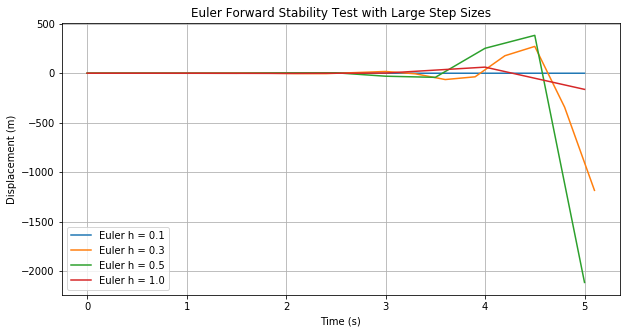

In [107]:
# Plot Euler stability behavior with larger step sizes

unstable_h_values = [0.1, 0.3, 0.5, 1.0]

plt.figure(figsize=(10, 5))

for h in unstable_h_values:
    
    t_values, y_values, v_values = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'Euler h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler Forward Stability Test with Large Step Sizes')
plt.legend()
plt.grid(True)
plt.show()

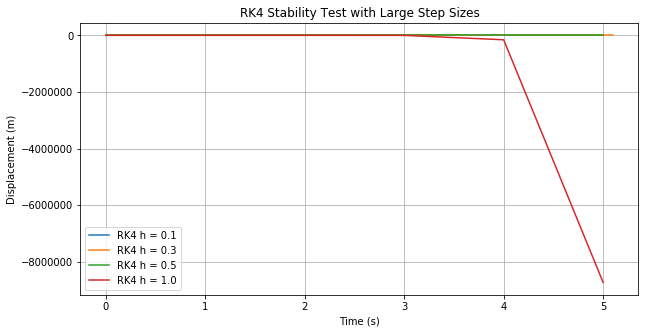

In [108]:
# Plot RK4 stability behavior with larger step sizes

plt.figure(figsize=(10, 5))

for h in unstable_h_values:
    
    t_values, y_values, v_values = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    plt.plot(t_values, y_values, label=f'RK4 h = {h}')

plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('RK4 Stability Test with Large Step Sizes')
plt.legend()
plt.grid(True)
plt.show()

### Analytical Solution:

Governing Second-Order ODE:

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$ Becomes $$\frac{d^2y}{dt^2} + (\frac{c}{m})\frac{dy}{dt} + (\frac{k}{m})y = 0$$

After Solving Using the Characteristic Equation and Initial Condition, Find Analytical Solution:

In [98]:
# Checked Using Claude (CHECK AFTER DOING DATA TO MAKE SURE OF CORRECT FORMULA)

# Analytical solution for underdamped case

alpha = c / (2 * m)
beta_n = np.sqrt(k / m)
beta_d = np.sqrt(beta_n**2 - alpha**2)

C1 = y_0
C2 = (v_0 + alpha * C1) / beta_d

def analytical_solution(t):
    return np.exp(-alpha * t) * (C1 * np.cos(beta_d * t) + C2 * np.sin(beta_d * t))

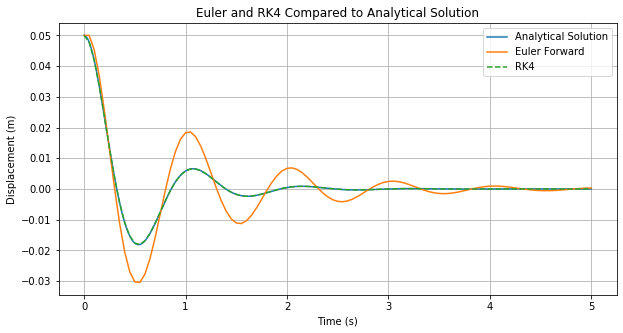

In [109]:
# Plot analytical solution against Euler and RK4 for one step size

h = 0.05

t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)

t_exact = np.linspace(t_start, t_end, 1000)
y_exact = analytical_solution(t_exact)

plt.figure(figsize=(10, 5))
plt.plot(t_exact, y_exact, label='Analytical Solution')
plt.plot(t_euler, y_euler, label='Euler Forward')
plt.plot(t_rk4, y_rk4, label='RK4', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Euler and RK4 Compared to Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
# Function to calculate average absolute error

def calculate_average_error(t_values, y_values):
    
    y_exact = analytical_solution(t_values)
    error = np.abs(y_exact - y_values)
    avg_error = np.mean(error)
    
    return avg_error

In [101]:
# Error vs step size for Euler and RK4

error_h_values = [0.1, 0.05, 0.025, 0.01]

euler_errors = np.zeros(len(error_h_values))
rk4_errors = np.zeros(len(error_h_values))

for index, h in enumerate(error_h_values):
    
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y_0, v_0)
    t_rk4, y_rk4, v_rk4 = rk4_method(h, m, c, k, t_start, t_end, y_0, v_0)
    
    euler_errors[index] = calculate_average_error(t_euler, y_euler)
    rk4_errors[index] = calculate_average_error(t_rk4, y_rk4)

print("Euler Errors:", euler_errors)
print("RK4 Errors:", rk4_errors)

Euler Errors: [0.02939375 0.00333436 0.00113767 0.00038408]
RK4 Errors: [1.57237303e-05 9.12709647e-07 5.50168126e-08 1.37703933e-09]


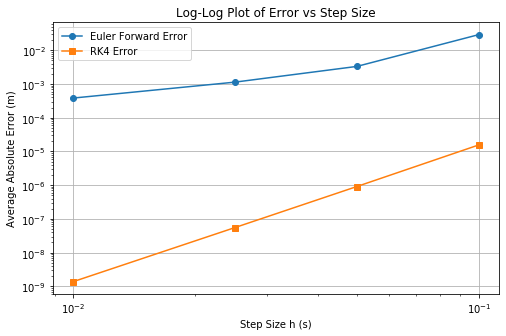

In [102]:
# Log-log plot of error vs step size

plt.figure(figsize=(8, 5))

plt.loglog(error_h_values, euler_errors, 'o-', label='Euler Forward Error')
plt.loglog(error_h_values, rk4_errors, 's-', label='RK4 Error')
plt.xlabel('Step Size h')
plt.ylabel('Average Absolute Error (m)')
plt.title('Log-Log Plot of Error vs Step Size')
plt.legend()
plt.grid(True)
plt.show()

In [103]:
# Estimate convergence slopes

euler_slope = np.polyfit(np.log(error_h_values), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(error_h_values), np.log(rk4_errors), 1)[0]

print("Euler estimated convergence slope:", euler_slope)
print("RK4 estimated convergence slope:", rk4_slope)

Euler estimated convergence slope: 1.8272975110752634
RK4 estimated convergence slope: 4.0559285587767215


Discussion of Stable vs. Unstable Behavior (CHANGE)

For this car suspension system, stable behavior means the displacement oscillates briefly and then decays back toward zero. This matches the physics of a damped suspension because the shock absorber removes energy from the system.

Unstable behavior would look like the displacement growing, oscillating too aggressively, or failing to decay. This would be non-physical because a passive damped suspension should not add energy after the car hits a bump.

Euler’s Forward Method becomes less reliable when the step size is too large because its approximation is based only on the current slope. RK4 is more reliable because it uses four slopes per step and has a larger stability region than Euler. The RK4 lecture specifically notes that RK4 has a larger stability region but is still conditionally stable, meaning the step size still matters.

Physical Interpretation (CHANGE):
    
Physically, the car body should start at the initial displacement of 0.05 m and gradually return to equilibrium. Since damping is included, each oscillation should be smaller than the previous one.

If the numerical method predicts that the car keeps bouncing higher, that result is not caused by the actual suspension model. It is caused by numerical instability. This connects directly to the course idea that errors are inevitable in discretization and that step size creates a tradeoff between accuracy, stability, and speed.

Overall, RK4 gives a more physically realistic and numerically stable solution for this car suspension model. Euler’s Forward Method is useful for showing the basic time-stepping idea, but RK4 is better for engineering simulations where accuracy and stability matte

# SECTION 6: Conclusion

In this project, I modeled a car suspension system as a damped spring-mass system and solved the second-order ODE using Euler’s Forward Method and RK4. The model represented one corner of a 2024 Toyota Camry Hybrid after hitting a speed bump, where the car body begins with an initial displacement and then returns toward equilibrium because of damping.

RK4 performed better than Euler’s Forward Method. Euler was easier to implement and only required one slope calculation per step, but it became less accurate as the step size increased. RK4 required four slope calculations per step, but it stayed much closer to the analytical solution and produced a smoother, more stable response. This matches the course idea that RK4 improves accuracy by using four intermediate slopes instead of relying only on the slope at the beginning of the interval.

The main tradeoff was computational cost versus accuracy. Euler is cheaper per step, but it needs a much smaller step size to reach the same accuracy as RK4. RK4 is more expensive per step, but because it is fourth-order accurate, it can often achieve better results without requiring extremely small time steps.

For a practical engineering simulation like car suspension modeling, RK4 is the better method. A suspension response should decay over time, not grow or bounce unrealistically. When Euler became unstable at larger step sizes, it produced behavior that did not match the physical system. RK4 gave a more reliable prediction of how the suspension would actually respond after a bump.

Overall, this project showed that numerical methods are not just about getting an answer, but about choosing a method that is accurate, stable, and physically meaningful. The key lesson is that step size and method selection both matter. A simple method like Euler can explain the basic idea of time stepping, but RK4 is more appropriate when accuracy and stability are important.

Citations:
- Claude: https://claude.ai/new